<a href="https://colab.research.google.com/github/mohameddhameem/WhisperCast/blob/master/Speech_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scenario 1- Accuracy + multilingual + local languages + batch: OK (total = 22)
Scenario 2 - Internal English-only + low cost: OK (total = 17)
Scenario 3 - External + low latency + real-time + multilingual: OK (total = 25)
Scenario 4 - Needs customization / fine-tuning: OK (total = 21)


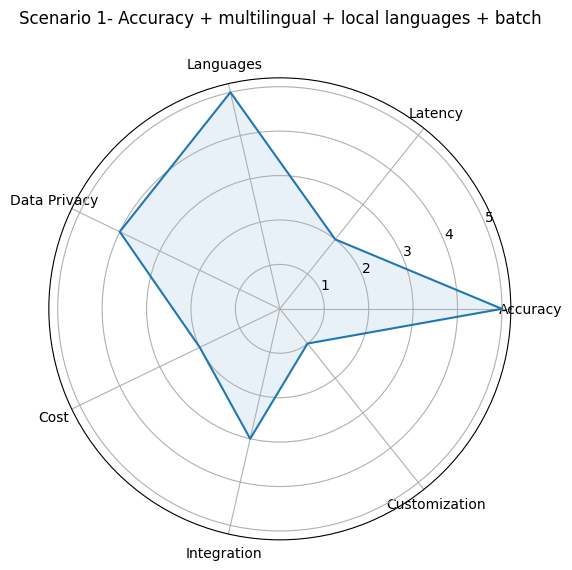

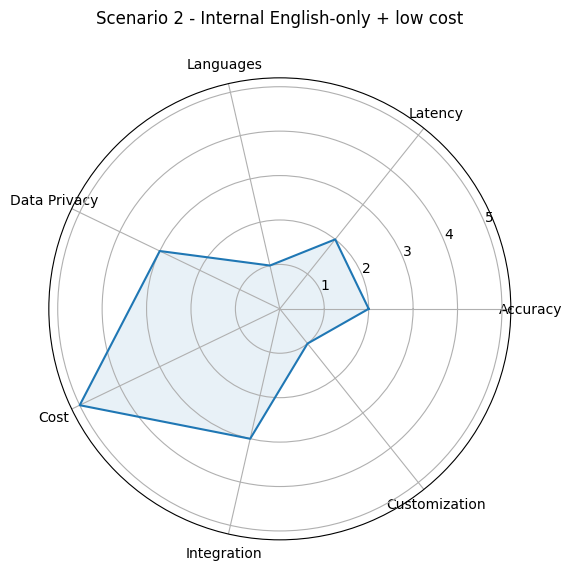

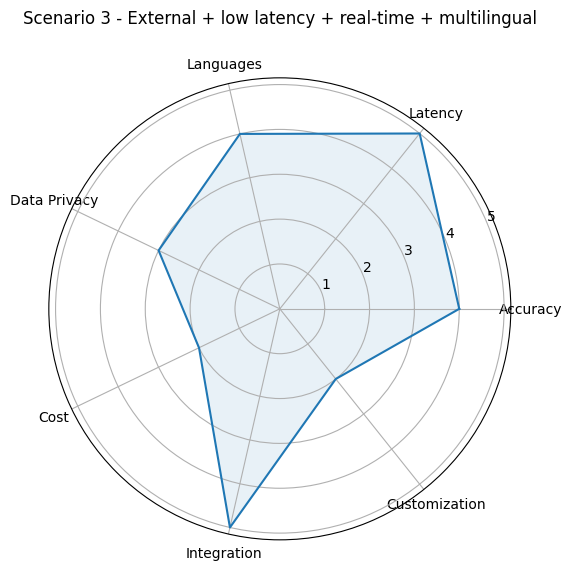

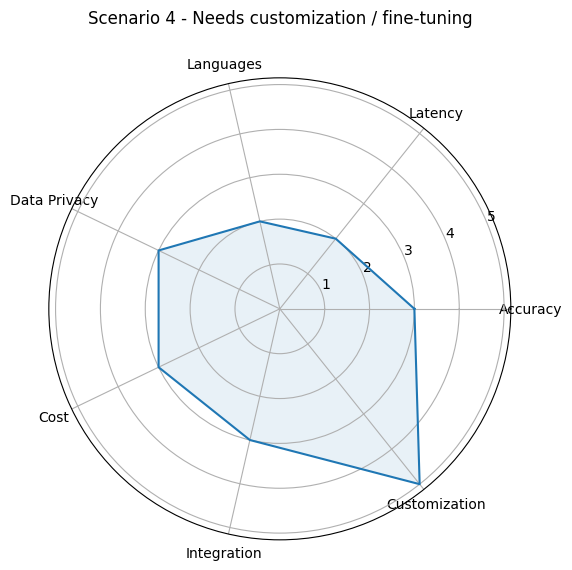

In [4]:
import matplotlib.pyplot as plt
import numpy as np

criteria = [
    "Accuracy",
    "Latency",
    "Languages",
    "Data Privacy",
    "Cost",
    "Integration",
    "Customization"
]

MAX_TOTAL = 25
MIN_SCORE = 1
MAX_SCORE = 5

# Scoring dictionary (you can modify later)
scores = {
    "Scenario 1- Accuracy + multilingual + local languages + batch": [5, 2, 5, 4, 2, 3, 1],
    "Scenario 2 - Internal English-only + low cost": [2, 2, 1, 3, 5, 3, 1],
    "Scenario 3 - External + low latency + real-time + multilingual": [4, 5, 4, 3, 2, 5, 2],
    "Scenario 4 - Needs customization / fine-tuning": [3, 2, 2, 3, 3, 3, 5],
}

def validate_scores(scores_dict):
    for scenario, values in scores_dict.items():

        # Check range 1–5
        for v in values:
            if v < MIN_SCORE or v > MAX_SCORE:
                raise ValueError(
                    f"{scenario} has a value out of allowed range (1–5): {values}"
                )

        total = sum(values)
        if total > MAX_TOTAL:
            raise ValueError(
                f"{scenario} exceeds MAX_TOTAL {MAX_TOTAL} → total = {total}. "
                f"Please rebalance priorities."
            )
        print(f"{scenario}: OK (total = {total})")

validate_scores(scores)

# Radar Plot Function
N = len(criteria)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def plot_radar(scenario, values):
    values = values + values[:1]

    fig = plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.1)

    plt.xticks(angles[:-1], criteria)
    ax.set_title(scenario, y=1.1)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["1", "2", "3", "4", "5"])

    # Generate a safe filename from the scenario name
    filename = f"{scenario.replace(' ', '_').replace('/', '_').replace('+', '_').replace('-', '_').replace(':', '_').replace(',', '_')}.png"
    plt.savefig(filename)
    plt.show()

for scenario, vals in scores.items():
    plot_radar(scenario, vals)
